In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/rajpurkarlab/medgemma-4b-it-crimson

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/rajpurkarlab/medgemma-4b-it-crimson)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# 1. Accept Colab default + CRIMSON’s strict deps
!pip uninstall -y CRIMSON CRIMSON-score
!pip cache purge

# 2. Install what CRIMSON requires (matching their pyproject.toml)
!pip install numpy>=2.4.3 -q
!pip install openai>=2.26.0 torch>=2.10.0 transformers>=5.3.0 \
                peft>=0.18.1 accelerate>=1.13.0 \
                sentence-transformers>=5.2.3 \
                scikit-learn>=1.8.0 scipy>=1.17.1 tqdm>=4.67.3 \
                pyyaml>=6.0.3 pydantic>=2.12.5 \
                pandas>=3.0.1 \
                Pillow>=12.1.1 \
                -q

# 3. Install CRIMSON from source
!pip install git+https://github.com/rajpurkarlab/CRIMSON.git -q

# 4. TELL pip to ignore the conflicting complains (safe; Colab ships this way)
import warnings
warnings.filterwarnings("ignore", module="pip")

# 5. Restart kernel
import os
os.kill(os.getpid(), 9)


Files removed: 0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB

In [ ]:
from CRIMSON.generate_score import CRIMSONScore
import pandas as pd
from google.colab import files
import time

df = pd.read_csv("CLEAR_dev_cleaned_to_use.csv")
scorer = CRIMSONScore(model_name="CRIMSONScore/medgemma-4b-it-crimson")

print(f"🚀 Starting {len(df)} rows (~66 min)...")

results = []
for idx, row in df.iterrows():
    try:
        result = scorer.evaluate(
            reference_findings=row['Report_Content'],
            predicted_findings=row['mistral_finetuned_lay_en'],
            patient_context={"age": str(row['Exam_Age'])},
            include_guidelines=False
        )
        results.append({
            'case_id': row['Case no. Identifier'],
            'age': row['Exam_Age'],
            'elderly': row['is_elderly'],
            'prompt_id': row['prompt_id'],
            **result  # crimson_score + error_counts
        })
        print(f"✅ {idx+1}/{len(df)}: {result['crimson_score']:.3f}")

        # Save every 50 rows (safety)
        if (idx+1) % 50 == 0:
            pd.DataFrame(results).to_csv(f"crimson_progress_{idx+1}.csv", index=False)
            print(f"💾 Progress saved at row {idx+1}")

    except Exception as e:
        print(f"❌ Row {idx}: {e}")
        results.append({'case_id': row['Case no. Identifier'], 'error': str(e)})

    time.sleep(0.1)  # Rate limit

df_final = pd.DataFrame(results)
df_final.to_csv("crimson_full_198.csv", index=False)
files.download("crimson_full_198.csv")
print("🎉 FULL FYP RESULTS!")

Loading HuggingFace model: CRIMSONScore/medgemma-4b-it-crimson


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/7.76G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/444 [00:00<?, ?it/s]

...

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ 10/198: 0.500
✅ 11/198: 1.000
✅ 12/198: 1.000
✅ 13/198: 1.000
✅ 14/198: 0.611
✅ 15/198: 1.000
✅ 16/198: 1.000
✅ 17/198: 0.857
✅ 18/198: 1.000
✅ 19/198: -0.333
✅ 20/198: 0.000
✅ 21/198: 1.000
✅ 22/198: 1.000
✅ 23/198: 1.000
✅ 24/198: 1.000
✅ 25/198: 1.000
✅ 26/198: 1.000
✅ 27/198: 0.905
✅ 28/198: 1.000
✅ 29/198: 0.333
✅ 30/198: -0.500
✅ 31/198: 0.833
✅ 32/198: 0.333
✅ 33/198: 1.000
✅ 34/198: 0.750
✅ 35/198: 1.000
✅ 36/198: 1.000
✅ 37/198: -0.333
✅ 38/198: -0.167
✅ 39/198: 1.000
✅ 40/198: 0.500
✅ 41/198: -0.333
✅ 42/198: 1.000
✅ 43/198: 1.000
✅ 44/198: 1.000
✅ 45/198: 0.667
✅ 46/198: 1.000
✅ 47/198: 1.000
✅ 48/198: 1.000
✅ 49/198: 1.000
✅ 50/198: 1.000
💾 Progress saved at row 50
✅ 51/198: 0.600
✅ 52/198: 0.417
✅ 53/198: 1.000
✅ 54/198: 1.000
✅ 55/198: 1.000
✅ 56/198: 1.000
✅ 57/198: 1.000
✅ 58/198: 0.750
✅ 59/198: 1.000
✅ 60/198: 1.000
✅ 61/198: 1.000
✅ 62/198: 0.778
✅ 63/198: 1.000
✅ 64/198: 0.800
✅ 65/198: 1.000
✅ 66/198: 0.444
✅ 67/198: 1.000
✅ 68/198: 0.571
✅ 69/198: 1.000
✅ 70/198

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 FULL FYP RESULTS!


Columns: ['case_id', 'age', 'elderly', 'prompt_id', 'raw_evaluation', 'error_counts', 'weighted_error_counts', 'metrics', 'crimson_score', 'error']
Shape: (198, 10)

CRIMSON RESULTS SUMMARY (198 cases)
Average CRIMSON score: 0.8536
CRIMSON range: -0.5000 - 1.0000

OMISSIONS & HALLUCINATIONS
----------------------------------------
Total false findings (hallucinations): 25
Total missing findings (omissions): 64
Total attribute errors: 369

PER-CASE AVERAGES (justifies 'good enough' pipeline)
----------------------------------------
Avg hallucinations/case: 0.126
Avg omissions/case: 0.323
Avg attribute errors/case: 1.864

FYP TABLE: BY GROUP
----------------------------------------
                  crimson_score       false_findings missing_findings
                           mean count           mean             mean
elderly prompt_id                                                    
False   1.0              0.9099   103         0.0388           0.2233
True    2.0              0.7970

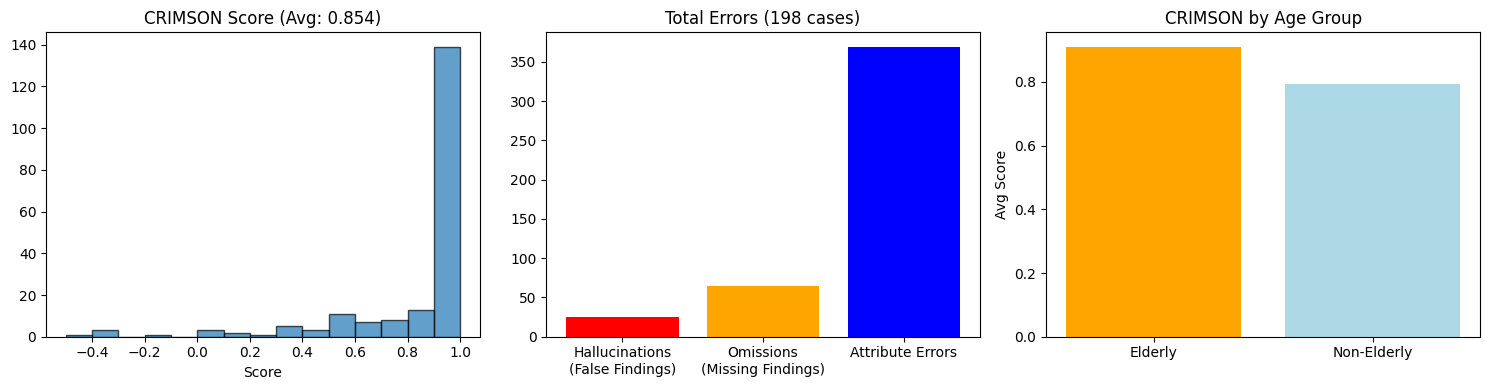

✅ THESIS PLOT: crimson_thesis_plot.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv("crimson_full_198.csv")

print("Columns:", df.columns.tolist())  # Shows exact column names
print(f"Shape: {df.shape}")

# Parse the error_counts string like "{'false_findings': 0, 'missing_findings': 2, 'attribute_errors': 4}"
def parse_error_counts(error_str):
    if pd.isna(error_str):
        return pd.Series({'false_findings': 0, 'missing_findings': 0, 'attribute_errors': 0})

    # Convert string to dict and extract counts
    try:
        # Remove outer quotes and eval safely
        clean_str = error_str.strip().strip('"').replace("'", '"')
        error_dict = eval(clean_str)
        return pd.Series({
            'false_findings': error_dict.get('false_findings', 0),
            'missing_findings': error_dict.get('missing_findings', 0),
            'attribute_errors': error_dict.get('attribute_errors', 0)
        })
    except:
        return pd.Series({'false_findings': 0, 'missing_findings': 0, 'attribute_errors': 0})

df[['false_findings', 'missing_findings', 'attribute_errors']] = df['error_counts'].apply(parse_error_counts)

# === YOUR THESIS SUMMARY ===
print("\n" + "="*60)
print("CRIMSON RESULTS SUMMARY (198 cases)")
print("="*60)
print(f"Average CRIMSON score: {df['crimson_score'].mean():.4f}")
print(f"CRIMSON range: {df['crimson_score'].min():.4f} - {df['crimson_score'].max():.4f}")

print("\nOMISSIONS & HALLUCINATIONS")
print("-" * 40)
print(f"Total false findings (hallucinations): {df['false_findings'].sum():.0f}")
print(f"Total missing findings (omissions): {df['missing_findings'].sum():.0f}")
print(f"Total attribute errors: {df['attribute_errors'].sum():.0f}")

print("\nPER-CASE AVERAGES (justifies 'good enough' pipeline)")
print("-" * 40)
print(f"Avg hallucinations/case: {df['false_findings'].mean():.3f}")
print(f"Avg omissions/case: {df['missing_findings'].mean():.3f}")
print(f"Avg attribute errors/case: {df['attribute_errors'].mean():.3f}")

# FYP table: groupby elderly/prompt_id
print("\nFYP TABLE: BY GROUP")
print("-" * 40)
group_summary = df.groupby(['elderly', 'prompt_id']).agg({
    'crimson_score': ['mean', 'count'],
    'false_findings': 'mean',
    'missing_findings': 'mean'
}).round(4)
print(group_summary)

# Save clean CSV
summary_df = df[['case_id', 'age', 'elderly', 'prompt_id', 'crimson_score',
                'false_findings', 'missing_findings', 'attribute_errors']].copy()
summary_df.to_csv("crimson_summary_clean.csv", index=False)
print("\n✅ CLEAN SUMMARY CSV: crimson_summary_clean.csv")

# Thesis plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['crimson_score'], bins=15, alpha=0.7, edgecolor='black')
axes[0].set_title('CRIMSON Score (Avg: {:.3f})'.format(df['crimson_score'].mean()))
axes[0].set_xlabel('Score')

error_totals = [df['false_findings'].sum(), df['missing_findings'].sum(), df['attribute_errors'].sum()]
axes[1].bar(['Hallucinations\n(False Findings)', 'Omissions\n(Missing Findings)', 'Attribute Errors'],
            error_totals, color=['red', 'orange', 'blue'])
axes[1].set_title('Total Errors (198 cases)')

elderly_avg = df.groupby('elderly')['crimson_score'].mean()
axes[2].bar(['Elderly', 'Non-Elderly'], elderly_avg.values, color=['orange', 'lightblue'])
axes[2].set_title('CRIMSON by Age Group')
axes[2].set_ylabel('Avg Score')

plt.tight_layout()
plt.savefig("crimson_thesis_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ THESIS PLOT: crimson_thesis_plot.png")
